In [1]:
import pandas as pd

df = pd.read_csv("../data/processed/telco_customer_churn_features.csv")

In [2]:
df.head()

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,LTV,AnnualCharges,ServiceCount
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,29.85,358.2,1
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,1936.30,683.4,2
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,107.70,646.2,2
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,1903.50,507.6,3
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,141.40,848.4,0


In [3]:
df.shape

(7043, 24)

In [4]:
df.columns.tolist()

['CustomerID',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'Tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'LTV',
 'AnnualCharges',
 'ServiceCount']

In [5]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

### active customer dataset

In [6]:
active_df = df[df["Churn"] == "No"].copy()

active_df = active_df.drop(columns=["LTV"])

In [7]:
active_df.shape

(5174, 23)

In [8]:
active_df.columns.tolist()

['CustomerID',
 'Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'Tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'AnnualCharges',
 'ServiceCount']

In [9]:
active_df[["MonthlyCharges", "TotalCharges", "AnnualCharges"]].describe()

,MonthlyCharges,TotalCharges,AnnualCharges
count,5174.000000,5174.000000,5174.000000
mean,61.265124,2549.911442,735.181484
std,31.092648,2329.954215,373.111777
min,18.250000,0.000000,219.000000
25%,25.100000,572.900000,301.200000
50%,64.425000,1679.525000,773.100000
75%,88.400000,4262.850000,1060.800000
max,118.750000,8672.450000,1425.000000


In [10]:
active_df[["MonthlyCharges", "TotalCharges", "AnnualCharges"]].corr()

,MonthlyCharges,TotalCharges,AnnualCharges
MonthlyCharges,1.000000,0.756874,1.000000
TotalCharges,0.756874,1.000000,0.756874
AnnualCharges,1.000000,0.756874,1.000000


In [11]:
X = active_df.drop(
    columns=[
        "CustomerID",
        "Churn",
        "TotalCharges",
        "MonthlyCharges",
        "Tenure",
        "AnnualCharges"
    ]
)

y = active_df["TotalCharges"]

In [12]:
X.shape,y.shape

((5174, 17), (5174,))

##  Train-Test Split

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((4139, 17), (1035, 17), (4139,), (1035,))

## Identify Categorical and Numerical Features

In [15]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

categorical_cols, numeric_cols

(['Gender',
  'SeniorCitizen',
  'Partner',
  'Dependents',
  'PhoneService',
  'MultipleLines',
  'InternetService',
  'OnlineSecurity',
  'OnlineBackup',
  'DeviceProtection',
  'TechSupport',
  'StreamingTV',
  'StreamingMovies',
  'Contract',
  'PaperlessBilling',
  'PaymentMethod'],
 ['ServiceCount'])

##   Preprocessing Pipeline

In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols)
    ]
)

##  Build the Linear Regression Pipeline

In [17]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

##  Train the Linear Regression Model

In [18]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Gender','SeniorCitizen','Partner',...,'PaperlessBilling','PaymentMethod', 'ServiceCount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

##  Generate LTV Predictions

In [19]:
y_pred_linear = linear_model.predict(X_test)

In [20]:
y_pred_linear[:10]

array([-608.57432787, 1080.9928792 , -441.80069089, 1334.7637529 ,
        922.64753377,  277.16217758,  450.44639821,  349.92513574,
        119.70220342, 5538.34093146])

##  Evaluate Linear Regression

The model is evaluated on the unseen test set using three regression metrics:

- **MAE (Mean Absolute Error):** Measures the average absolute difference between actual and predicted lifetime revenue.
- **RMSE (Root Mean Squared Error):** Measures prediction error while giving greater weight to larger errors.
- **R² (R-squared):** Measures how much of the variation in lifetime revenue is explained by the model.

Lower MAE and RMSE indicate better performance, while a higher R² indicates better performance.

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MAE : 810.9576730857574
RMSE: 1041.4547129005316
R²  : 0.8005429654295128


##  Random Forest Regression

In [22]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [23]:
rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Gender','SeniorCitizen','Partner',...,'PaperlessBilling','PaymentMethod', 'ServiceCount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

##  Generate Random Forest Predictions

In [24]:
y_pred_rf = rf_model.predict(X_test)

In [25]:
y_pred_rf[:10]

array([ 134.08515847, 1100.93731298,  707.49999226,  814.11880636,
        354.39444311,  327.12746258,  846.48370833,  602.1016627 ,
        295.19806515, 6974.0159875 ])

##  Evaluate Random Forest Regression

In [26]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Regression")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Regression
MAE : 722.6854326243083
RMSE: 1028.2878056404788
R²  : 0.8055544762997545


In [27]:
import xgboost
print(xgboost.__version__)

3.4.0


##  XGBoost Regression

In [28]:
from xgboost import XGBRegressor

xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42,
            objective="reg:squarederror"
        ))
    ]
)

In [29]:
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](17,)","['Gender','SeniorCitizen','Partner',...,'PaperlessBilling','PaymentMethod', 'ServiceCount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,17
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. Th

##  Generate XGBoost Predictions

In [30]:
y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb[:10]

array([  60.97378,  987.4279 ,  331.7089 ,  957.1869 ,  729.41724,
        395.2739 ,  596.05206,  667.35876,  377.5226 , 5827.625  ],
      dtype=float32)

##  Evaluate XGBoost Regression


In [31]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Regression")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost Regression
MAE : 673.5986172109409
RMSE: 947.29892739366
R²  : 0.8349776871065614


##  Compare Regression Models

In [32]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_xgb
    ],
    "R2": [
        r2_linear,
        r2_rf,
        r2_xgb
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,810.957673,1041.454713,0.800543
1,Random Forest,722.685433,1028.287806,0.805554
2,XGBoost,673.598617,947.298927,0.834978


* **XGBoost** is selected as LTV prediction model

##  Compare Actual vs Predicted LTV

In [33]:
comparison = pd.DataFrame({
    "Actual_LTV": y_test.values,
    "Predicted_LTV": y_pred_xgb
})

comparison.head(10)

,Actual_LTV,Predicted_LTV
0,20.15,60.973782
1,1414.80,987.427917
2,344.20,331.708893
3,1036.00,957.186890
4,886.70,729.417236
5,422.50,395.273895
6,882.55,596.052063
7,475.10,667.358765
8,465.45,377.522614
9,2964.00,5827.625000


##  XGBoost Hyperparameter Tuning

In [34]:
from sklearn.model_selection import RandomizedSearchCV

In [35]:
param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [36]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_grid,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=3,
    random_state=42,
    n_jobs=1
)

In [37]:
xgb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [2, 3, ...], 'model__n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` dire

In [38]:
xgb_search.best_params_

{'model__subsample': 0.8,
 'model__n_estimators': 200,
 'model__max_depth': 4,
 'model__learning_rate': 0.03,
 'model__colsample_bytree': 0.8}

In [39]:
xgb_search.best_score_

np.float64(-693.4681761185951)

## Evaluate Tuned XGBoost Model

In [40]:
best_xgb = xgb_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test)

In [41]:
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned XGBoost Regression")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned XGBoost Regression
MAE : 673.9383585199181
RMSE: 943.946212500322
R²  : 0.8361437259748201


In [42]:
active_df["Predicted_LTV"] = best_xgb.predict(active_df)

In [43]:
active_df[["CustomerID", "Predicted_LTV"]].head(10)

,CustomerID,Predicted_LTV
0,7590-VHVEG,915.802795
1,5575-GNVDE,1664.042236
3,7795-CFOCW,1858.733521
6,1452-KIOVK,2499.930908
7,6713-OKOMC,279.949158
9,6388-TABGU,2005.713379
10,9763-GRSKD,715.310364
11,7469-LKBCI,980.502869
12,8091-TTVAX,5290.101562
14,5129-JLPIS,3124.096680


In [46]:
comparison = pd.DataFrame({
    "Actual_LTV": y_test.values,
    "Predicted_LTV": y_pred_tuned
})

comparison.head(50)

,Actual_LTV,Predicted_LTV
0,20.15,101.261467
1,1414.80,971.948486
2,344.20,356.451691
3,1036.00,936.541138
4,886.70,740.783752
5,422.50,407.587830
6,882.55,700.927612
7,475.10,636.944885
8,465.45,404.814178
9,2964.00,5997.417480


## Review Model Features

Before training the final LTV models, we verify that the target variable and its direct components are not being used as predictor variables.

In [47]:
X.columns.tolist()

['Gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'ServiceCount']

## Feature Importance

Feature importance is analyzed using the tuned XGBoost regression model to identify the customer characteristics that contribute most to LTV prediction.

In [48]:
# Get the preprocessing pipeline
preprocessor = best_xgb.named_steps["preprocessor"]

# Get feature names after One-Hot Encoding
feature_names = preprocessor.get_feature_names_out()

# Get feature importance from the tuned XGBoost model
xgb_model = best_xgb.named_steps["model"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
33,cat__StreamingMovies_Yes,0.243184
43,num__ServiceCount,0.153119
30,cat__StreamingTV_Yes,0.138762
12,cat__MultipleLines_Yes,0.071383
21,cat__OnlineBackup_Yes,0.067770
34,cat__Contract_Month-to-month,0.042498
13,cat__InternetService_DSL,0.041499
14,cat__InternetService_Fiber optic,0.037996
35,cat__Contract_One year,0.025210
36,cat__Contract_Two year,0.022252


## Visualize Feature Importance

The top features are visualized to make the model's key predictive drivers easier to interpret.

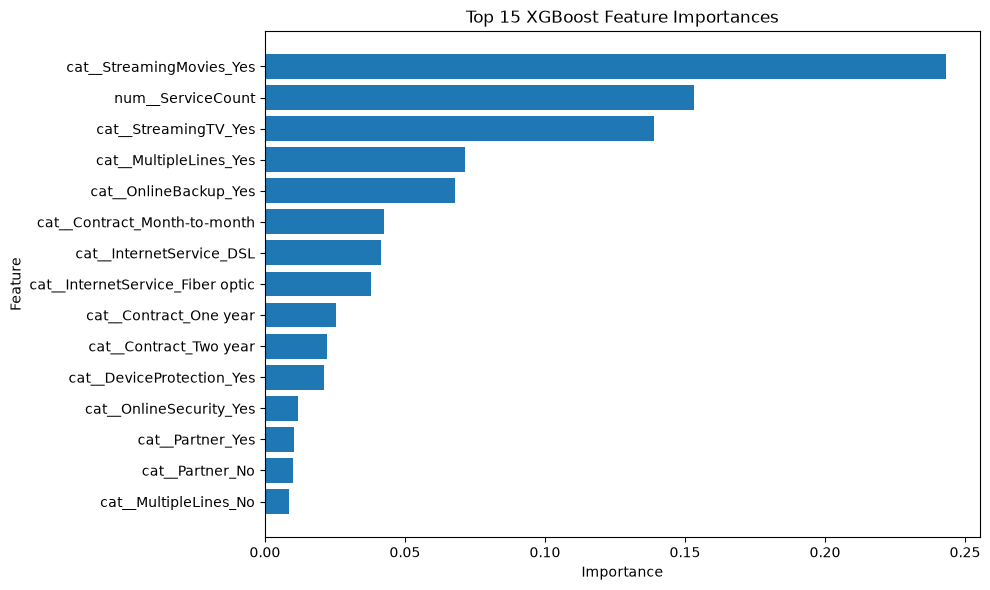

In [49]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

## Actual vs Predicted LTV

The actual and predicted LTV values are compared visually to assess how closely the tuned XGBoost model estimates customer lifetime revenue.

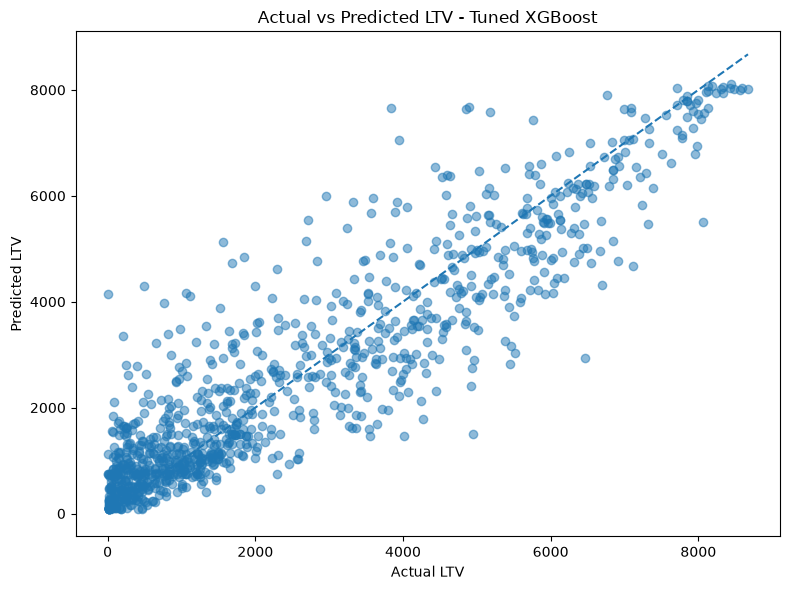

In [50]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_tuned, alpha=0.5)

# Perfect prediction line
min_value = min(y_test.min(), y_pred_tuned.min())
max_value = max(y_test.max(), y_pred_tuned.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual LTV")
plt.ylabel("Predicted LTV")
plt.title("Actual vs Predicted LTV - Tuned XGBoost")

plt.tight_layout()
plt.show()

- The actual-vs-predicted plot shows a strong positive relationship, although some prediction errors remain, particularly for mid-to-high LTV customers.

## Save Final LTV Model

The tuned XGBoost pipeline is saved so that it can be reused for LTV predictions without retraining the model.

In [51]:
import joblib

joblib.dump(best_xgb, "../models/ltv_xgboost_model.pkl")

['../models/ltv_xgboost_model.pkl']

In [52]:
import os

os.path.exists("../models/ltv_xgboost_model.pkl")

True

##  Final Customer LTV Dataset

The tuned XGBoost regression model is used to estimate the Lifetime Value (LTV) of each active customer.

The predicted LTV will be used to identify high-value customers and support targeted retention campaigns.

In [53]:
# Generate predicted LTV for all active customers
active_df["Predicted_LTV"] = best_xgb.predict(active_df)

In [54]:
ltv_output = active_df[
    ["CustomerID", "MonthlyCharges", "Tenure", "Predicted_LTV"]
].copy()

ltv_output.head(10)

,CustomerID,MonthlyCharges,Tenure,Predicted_LTV
0,7590-VHVEG,29.85,1,915.802795
1,5575-GNVDE,56.95,34,1664.042236
3,7795-CFOCW,42.30,45,1858.733521
6,1452-KIOVK,89.10,22,2499.930908
7,6713-OKOMC,29.75,10,279.949158
9,6388-TABGU,56.15,62,2005.713379
10,9763-GRSKD,49.95,13,715.310364
11,7469-LKBCI,18.95,16,980.502869
12,8091-TTVAX,100.35,58,5290.101562
14,5129-JLPIS,105.50,25,3124.096680


## Rank Customers by Predicted LTV

Customers are ranked based on their predicted Lifetime Value (LTV). This helps identify customers with the highest expected revenue and supports prioritization of retention efforts.

In [55]:
ltv_output = ltv_output.sort_values(
    by="Predicted_LTV",
    ascending=False
).reset_index(drop=True)

ltv_output.head(10)

,CustomerID,MonthlyCharges,Tenure,Predicted_LTV
0,5451-YHYPW,115.75,72,8102.167969
1,0907-HQNTS,113.00,70,8102.167969
2,8628-MFKAX,116.75,72,8102.167969
3,9298-WGMRW,115.50,72,8073.096191
4,5038-ETMLM,113.65,72,8073.096191
5,6650-BWFRT,117.15,72,8068.149414
6,3669-WHAFY,115.15,71,8068.149414
7,2121-JAFOM,115.55,72,8068.149414
8,9239-GZHZE,113.65,72,8068.149414
9,8606-CIQUL,115.75,72,8060.618652


## Customer LTV Segmentation

Active customers are segmented into High, Medium, and Low LTV groups based on their predicted Lifetime Value.

These segments can help marketing teams prioritize customers for retention and engagement campaigns.

In [60]:
ltv_output["LTV_Segment"] = pd.qcut(
    ltv_output["Predicted_LTV"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

ltv_output.head(10)

,CustomerID,MonthlyCharges,Tenure,Predicted_LTV,LTV_Segment
0,5451-YHYPW,115.75,72,8102.167969,High
1,0907-HQNTS,113.00,70,8102.167969,High
2,8628-MFKAX,116.75,72,8102.167969,High
3,9298-WGMRW,115.50,72,8073.096191,High
4,5038-ETMLM,113.65,72,8073.096191,High
5,6650-BWFRT,117.15,72,8068.149414,High
6,3669-WHAFY,115.15,71,8068.149414,High
7,2121-JAFOM,115.55,72,8068.149414,High
8,9239-GZHZE,113.65,72,8068.149414,High
9,8606-CIQUL,115.75,72,8060.618652,High


In [61]:
ltv_output["LTV_Segment"].value_counts()

LTV_Segment
Low       1730
High      1725
Medium    1719
Name: count, dtype: int64

## LTV Segment Summary

The active customer base is divided into three segments based on predicted LTV:

- **High LTV:** Customers with the highest predicted lifetime revenue.
- **Medium LTV:** Customers with moderate predicted lifetime revenue.
- **Low LTV:** Customers with the lowest predicted lifetime revenue.

These segments can be used to prioritize customer retention and marketing strategies.

In [65]:
segment_summary = ltv_output.groupby("LTV_Segment", observed=True).agg(
    Customer_Count=("CustomerID", "count"),
    Avg_Predicted_LTV=("Predicted_LTV", "mean"),
    Avg_Monthly_Charges=("MonthlyCharges", "mean"),
    Avg_Tenure=("Tenure", "mean")
).reset_index()

segment_summary

,LTV_Segment,Customer_Count,Avg_Predicted_LTV,Avg_Monthly_Charges,Avg_Tenure
0,Low,1730,590.937317,31.212601,21.358960
1,Medium,1719,1921.181152,60.364427,35.022106
2,High,1725,5181.070312,92.302319,56.366957


## LTV Segment Analysis by Contract Type

This analysis compares contract types across Low, Medium, and High LTV customer segments to identify customer groups associated with higher lifetime value.

In [66]:
# Add LTV segment to active customer data
active_analysis = active_df.merge(
    ltv_output[["CustomerID", "LTV_Segment"]],
    on="CustomerID",
    how="left"
)

# Compare contract types across LTV segments
contract_segment = pd.crosstab(
    active_analysis["Contract"],
    active_analysis["LTV_Segment"],
    normalize="index"
) * 100

contract_segment.round(2)

LTV_Segment,Low,Medium,High
Contract,,,
Month-to-month,46.04,40.18,13.78
One year,26.24,32.06,41.70
Two year,22.16,24.77,53.07


- Month-to-month customers are heavily represented in Low LTV.
- Two-year customers are heavily represented in High LTV.
- One-year contracts are more balanced but lean toward High LTV.

## LTV Segment Analysis by Internet Service

This analysis compares internet service types across LTV segments to identify customer groups associated with higher or lower predicted lifetime value.

In [67]:
internet_segment = pd.crosstab(
    active_analysis["InternetService"],
    active_analysis["LTV_Segment"],
    normalize="index"
) * 100

internet_segment.round(2)

LTV_Segment,Low,Medium,High
InternetService,,,
DSL,24.87,43.99,31.14
Fiber optic,7.12,30.96,61.92
No,78.84,21.16,0.00


**Insight** : Fiber optic customers represent the strongest high-LTV segment, while customers without internet service are predominantly low-LTV customers. This suggests that internet service type is an important factor associated with customer lifetime value.

## LTV Segment Analysis by Payment Method

This analysis compares payment methods across LTV segments to identify payment groups associated with higher or lower predicted lifetime value.

In [68]:
payment_segment = pd.crosstab(
    active_analysis["PaymentMethod"],
    active_analysis["LTV_Segment"],
    normalize="index"
) * 100

payment_segment.round(2)

LTV_Segment,Low,Medium,High
PaymentMethod,,,
Bank transfer (automatic),20.14,34.14,45.72
Credit card (automatic),21.40,33.72,44.88
Electronic check,27.98,38.87,33.15
Mailed check,63.88,26.23,9.89


- Customers using automatic bank transfer and automatic credit card payments have the highest proportion of High-LTV customers, while mailed-check customers are predominantly in the Low-LTV segment. This indicates that payment method is associated with customer lifetime value and may help prioritize customer engagement strategies.